# Exercise 7

This exercise is based on Chapter 6 (Global Spatial Autocorrelation) of the Geographic Data Science book.

The material can be found in: `GSP538/gds_book/notebooks/06_spatial_autocorrelation.ipynb`

#### Notes on Textbook

- The authors discuss a "row standardized" spatial weights matrix a few times in the chapter, but this concept is not defined. Let's take the example of rook spatial weights for the 3x3 grid that started Chapter 4. The dense matrix representation is:

&nbsp;|0|1|2|3|4|5|6|7|8|
-|-|-|-|-|-|-|-|-|-|
__0__|0|1|0|1|0|0|0|0|0|
__1__|1|0|1|0|1|0|0|0|0|
__2__|0|1|0|0|0|1|0|0|0|
__3__|1|0|0|0|1|0|1|0|0|
__4__|0|1|0|1|0|1|0|1|0|
__5__|0|0|1|0|1|0|0|0|1|
__6__|0|0|0|1|0|0|0|1|0|
__7__|0|0|0|0|1|0|1|0|1|
__8__|0|0|0|0|0|1|0|1|0|

Row standardization means summing the values in each row, and then dividing the row by that sum as shown in the row standardized weights matrix below. The first row in the matrix above has two `1`s; these sum to `2`; after dividing the row by `2`, these `1`s become `0.50` in the matrix below. This process is repeated for each row.

&nbsp;|0|1|2|3|4|5|6|7|8|
-|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
__0__|0|0.50|0|0.50|0|0|0|0|0|
__1__|0.33|0|0.33|0|0.33|0|0|0|0|
__2__|0|0.50|0|0|0|0.50|0|0|0|
__3__|0.33|0|0|0|0.33|0|0.33|0|0|
__4__|0|0.25|0|0.25|0|0.25|0|0.25|0|
__5__|0|0|0.33|0|0.33|0|0|0|0.33|
__6__|0|0|0|0.50|0|0|0|0.50|0|
__7__|0|0|0|0|0.33|0|0.33|0|0.33|
__8__|0|0|0|0|0|0.50|0|0.50|0|


- This map of the United Kingdom might help when reading the chapter.

<img src="https://www.cgpplus.co.uk/getmedia/a8cc612f-28dd-45c7-9538-a2bf48558fbf/g2wae44-cover" width=600 height=600 />


#### Answer the following written questions

There is a blank Markdown cell after each question for your answer (double click in the blank cell to type your answer). Be sure to run your Markdown cells to format your answers.

1. Classic ideas of correlation were introduced earlier in the semester using Pearson's correlation coefficient. This chapter introduces spatial autocorrelation using Moran's I (and other measures). What is needed to compute classic correlation? What is needed to compute spatial autocorrelation? What is each measuring?

**Classic correlation** (e.g., Pearson's r) requires **two different variables** measured on the same set of observations. It measures the strength and direction of the linear relationship between those two variables — for example, the correlation between income and education level across census tracts.

**Spatial autocorrelation** (e.g., Moran's I) requires only **one variable** measured across observations that have known spatial locations, plus a **spatial weights matrix** that defines the neighbor relationships among those observations. It measures the degree to which values of that single variable at one location are similar to (or different from) values at nearby locations. In other words, it measures whether the spatial arrangement of values exhibits a non-random pattern — do similar values cluster together (positive autocorrelation) or do dissimilar values tend to neighbor each other (negative autocorrelation)?

2. Explain in your own words what a spatial lag is, why it can be characterized as a smoother and why it is so important for computing spatial autocorrelation measures. (Hint: be sure you have read to the end of the chapter before answering this.)

A **spatial lag** for a given observation is computed by multiplying the spatial weights matrix by the variable of interest: $Y_{sl} = \mathbf{W}Y$. For a single observation $i$, the spatial lag $y_{sl-i} = \sum_j w_{ij} y_j$. When the weights matrix is row-standardized, this computes the **weighted average** of the variable's values among observation $i$'s neighbors.

The spatial lag acts as a **smoother** because it replaces each observation's value with an average of its neighbors' values. This averaging process dampens local extremes — an unusually high or low value surrounded by moderate neighbors will be pulled toward the neighborhood mean. This produces a map that is visually smoother than the original, with less abrupt variation from one area to the next.

The spatial lag is critical for computing spatial autocorrelation because all the major measures rely on comparing each observation's value to its neighbors' values. Moran's I, for instance, is computed as the slope of the regression line in the Moran Plot, which is a scatterplot of a variable against its spatial lag. The join count statistic compares each observation's binary category to those of its neighbors. The Getis-Ord G statistic similarly examines the product of neighboring values. In every case, the spatial lag (or its conceptual equivalent) provides the mechanism for quantifying whether nearby observations have similar or dissimilar values — which is the essence of spatial autocorrelation.

3. The second equation under the "Spatial Lag" heading is:
    $$
    y_{sl-i} = \sum_j w_{ij} y_j
    $$
    
    - Use pen-and-paper to compute the value of $y_{sl-i}$ when $y_j$ contains the values $[9,3,4,2,8,6,5]$ and $w_{ij}$ contains $[0,0,1,1,1,1,0]$ (i.e., the binary weights case). Report the result.
    - Do this again for the same $y_j$ values, but now when $w_{ij}$ contains $[0,0,0.25,0.25,0.25,0.25,0]$ (i.e., the row standardized case). Report the result.
    - Compute the average of $4$, $2$, $8$, $6$. Report the result.
    - Explain why $y_{sl-i}$ is characterized as an "average" when $w_{ij}$ comes from a row standardized weights matrix. 
    

**Binary weights case:** $y_{sl-i} = \sum_j w_{ij} y_j = (0)(9)+(0)(3)+(1)(4)+(1)(2)+(1)(8)+(1)(6)+(0)(5) = 0+0+4+2+8+6+0 = \mathbf{20}$

**Row-standardized weights case:** $y_{sl-i} = \sum_j w_{ij} y_j = (0)(9)+(0)(3)+(0.25)(4)+(0.25)(2)+(0.25)(8)+(0.25)(6)+(0)(5) = 0+0+1+0.5+2+1.5+0 = \mathbf{5}$

**Average of 4, 2, 8, 6:** $(4+2+8+6)/4 = 20/4 = \mathbf{5}$

**Explanation:** When the weights matrix is row-standardized, each row sums to 1, and each non-zero weight equals $1/k$ where $k$ is the number of neighbors. The spatial lag formula then becomes $y_{sl-i} = \sum_j \frac{1}{k} y_j$ for each neighbor $j$, which is exactly the formula for the arithmetic mean of the neighbors' values. As demonstrated above, both the row-standardized spatial lag and the simple average produce the same result of 5. This is why the spatial lag with a row-standardized weights matrix is characterized as an "average" — it computes the mean value of the variable across the observation's neighbors.

4. What is the difference between the binary values that are needed for the join count statistic and a binary weights matrix?

The **binary values** needed for the join count statistic refer to the **data variable** itself — the variable being analyzed must have only two categories (e.g., Lightning vs. Arson, or Leave vs. Remain). Each observation is coded as either 0 or 1 based on which category it belongs to.

A **binary weights matrix**, on the other hand, refers to the **spatial weights matrix** that defines neighbor relationships. In a binary weights matrix, entries are either 0 (not neighbors) or 1 (neighbors), with no row standardization applied.

The join count statistic requires both: a binary data variable **and** a binary (non-standardized) spatial weights matrix. These are two different objects — one describes the attribute being studied and the other describes the spatial structure of the observations. The weights matrix must remain in its original binary form (not row-standardized) for the join count computation to work correctly.

5. What is the difference between the data needed to compute the join count statistic versus what is needed for the Moran's I statistic? What is the same?

**Differences:**
- The **join count statistic** requires a **binary (categorical) variable** — each observation belongs to one of two categories (e.g., 0 or 1). It also requires a **binary (non-standardized) spatial weights matrix**.
- **Moran's I** requires a **continuous variable** (e.g., percent vote, income) and typically uses a **row-standardized spatial weights matrix**.

**What is the same:**
- Both require a **spatial weights matrix** that defines the neighbor relationships among observations. Both use the weights matrix to compare each observation to its neighbors in order to assess whether the spatial pattern of values departs from randomness.

6. When the `esda` package conducts the statistical test for the join count statistic or Moran's I statistic, what is the null hypothesis? How does the package derive simulated values of the null hypothesis? How does this relate to the strategies for generating a distribution from the data science book at the beginning of the course?

**Null hypothesis:** The null hypothesis for both the join count statistic and Moran's I is **complete spatial randomness** — the observed spatial arrangement of values is no different from what would occur if values were randomly assigned to locations.

**Simulation approach:** The `esda` package derives simulated values using **random spatial permutations**. It takes the observed values and randomly shuffles them across the locations, then computes the statistic for each shuffled arrangement. This is repeated many times (999 by default), generating an **empirical reference distribution** of the statistic under the null hypothesis of spatial randomness. The observed statistic is then compared to this reference distribution. The **pseudo-p-value** (`p_sim`) is the proportion of simulated values that are at least as extreme as the observed statistic. A small p-value indicates that the observed pattern is unlikely to have arisen by chance, leading us to reject the null.

**Relation to data science strategies:** This permutation-based approach is a form of **simulation-based inference** (also called a randomization test), which was discussed in the data science book earlier in the course. Rather than relying on theoretical distributions with restrictive assumptions, it uses computational resampling to build an empirical distribution from the data itself, from which statistical significance can be assessed.

7. What are some differences between global Moran's I and global Getis and Ord's G? The textbook gives some description. You might find this page helpful too. https://pro.arcgis.com/en/pro-app/latest/tool-reference/spatial-statistics/h-how-high-low-clustering-getis-ord-general-g-spat.htm

| | Moran's I | Getis-Ord G |
|---|---|---|
| **What it measures** | Spatial autocorrelation — whether similar or dissimilar values cluster together | Spatial concentration — whether high or low values co-locate |
| **Autocorrelation type** | Detects both **positive** and **negative** spatial autocorrelation | Only detects **positive** spatial autocorrelation; cannot detect negative |
| **Variable requirements** | Works with any continuous variable (deviations from mean) | Designed for **positive variables with a natural origin** (e.g., counts, sizes) |
| **Weights matrix** | Typically uses row-standardized weights (e.g., contiguity, KNN) | Uses a **binary distance-band** weights matrix (not row-standardized) |
| **Interpretation of sign** | Positive I → similar values cluster; Negative I → dissimilar values are neighbors | A significant G indicates concentration of similar values (high-high or low-low clustering) |
| **Original design** | Designed for areal (polygon) data | Originally conceived for **point** data using a distance threshold, but can be applied to polygons |
| **Conceptual basis** | Based on cross-products of deviations from the mean (related to slope of Moran Plot) | Based on the ratio of the sum of weighted cross-products to the sum of all cross-products |

#### The following questions require you to run Python code.

The cell below imports GeoPandas and other packages, and the standard extra stuff to make things run smoother. Run this cell. 

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import geopandas as gpd
from shapely import Polygon

8. You will be working with precinct level 2020 presidential election data for Arizona.

   > The Upshot scraped and standardized precinct-level election results from around the country, and joined this tabular data to precinct GIS data to create a nationwide election map.
   
   https://www.kaggle.com/datasets/paultimothymooney/presidential-precinct-map-2020-election-results

    Run the cell below.
    - Explain each of the five lines
    - Despite Line 3 using a rectangle as an input, the resulting data presented in the map is not a rectangle. Why is this? (Note: this is a more of a GSP 531 question.)

    **If a map is not produced, click "Help" > "Toggle Developer Tools"; then close the panel the opens on the right.**

In [2]:
votes = gpd.read_file('data/az_precincts_2020.geojson')  #L1
maricopa = votes.loc[votes.cnty_name=='Maricopa',]       #L2
metro_phx = maricopa.loc[maricopa.within(Polygon([(-111.5,33.1),
                                                  (-112.755,33.1),
                                                  (-112.755,33.95),
                                                  (-111.5,33.95)])),]  #L3
metro_phx = metro_phx.to_crs(2223)  #L4
metro_phx.explore()  #L5

**Line-by-line explanation:**

- **L1:** Reads the GeoJSON file containing precinct-level 2020 presidential election results for Arizona into a GeoDataFrame called `votes`.
- **L2:** Filters `votes` to keep only precincts in Maricopa County, storing the result in `maricopa`.
- **L3:** Further filters `maricopa` to keep only precincts whose geometries fall entirely within a rectangular bounding box defined by four corner coordinates (roughly covering metropolitan Phoenix). The `Polygon` is constructed from longitude/latitude pairs and `within()` returns True only for precincts completely inside the rectangle.
- **L4:** Reprojects the resulting GeoDataFrame from its original CRS (EPSG:4326, WGS84 geographic coordinates) to EPSG:2223 (NAD83 Arizona State Plane, Central zone, in feet), a projected coordinate system appropriate for Arizona.
- **L5:** Produces an interactive map of the `metro_phx` GeoDataFrame using Folium.

**Why the map is not a rectangle:** The `within()` method on Line 3 selects only precincts whose **entire geometry** falls within the rectangle. Since precincts are irregularly-shaped polygons, those along the rectangle's boundary may overlap but not be entirely contained within it, so they are excluded. The result is a collection of irregular precinct polygons that happen to lie inside the rectangle — producing an irregular boundary rather than a clean rectangle.

9. Voting percents.
    - Add a column to `metro_phx` with the percent of the vote that went to the Democrat (Note: Multiply by 100 so the data looks like 24.3 not 0.243.)
    - Print out the first five rows of the GeoDataFrame after adding the column
    - Based on a visual inspection of the first five rows, which precinct had the highest percent and what was it?

In [3]:
metro_phx['pct_dem'] = (metro_phx['votes_dem'] / metro_phx['votes_total']) * 100
metro_phx.head()

,GEOID,votes_dem,votes_rep,votes_total,votes_per_sqkm,cnty_id,cnty_name,geometry,pct_dem
214,04013-0677 TRAMONTO,2452.0,3403.0,5938.0,355.9,013,Maricopa,"POLYGON ((649243.351 1017459.712, 649140.912 1...",41.293365
215,04013-0741 WOLF RUN,1193.0,2292.0,3497.0,468.9,013,Maricopa,"POLYGON ((634924.355 1041037.273, 635034.225 1...",34.114956
216,04013-0049 BISCUIT FLAT,898.0,1876.0,2806.0,44.6,013,Maricopa,"POLYGON ((632600.278 1022737.824, 632806.705 1...",32.002851
217,04013-0596 SIERRA PASS,2172.0,2047.0,4265.0,344.0,013,Maricopa,"POLYGON ((681202.798 966456.72, 680302.938 966...",50.926143
218,04013-0169 DEER VALLEY,946.0,1543.0,2528.0,91.2,013,Maricopa,"POLYGON ((648792.879 970933.74, 647551.549 971...",37.420886


Based on a visual inspection of the first five rows, the precinct with the highest percent Democratic vote is **SIERRA PASS** (row 217) with approximately **50.93%**.

10. The following cell produces a map of the election results for percent Democratic votes. 
    - Run the cell. (Note: you need to match the column name to what you used in the previous question.)
    - Explain why the particular values for `vmin` and `vmax` were chosen and their effect on the legend and resulting map. (Note: this is not asking you to define `vmin` and `vmax`, but the values assigned and their effect on the cartography of the map. Hint: inspect the range of values for percent Democratic votes before answering.)
    - Does the resulting map generally appear to be a case of positive spatial autocorrelation, negative spatial autocorrelation or neither? Explain.  

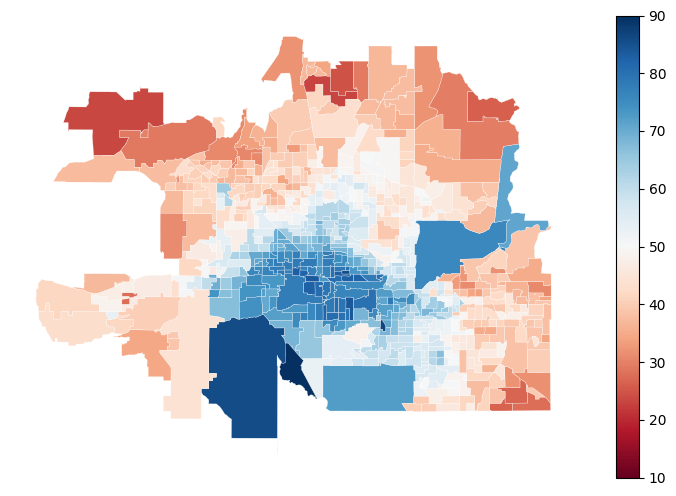

In [4]:
ax = metro_phx.plot(column='pct_dem', cmap='RdBu', legend=True, 
                    vmin=10, vmax=90, figsize=(10,6),
                    edgecolor="white", linewidth=0.2)
ax.set_axis_off();

In [5]:
print(f"Min pct_dem: {metro_phx['pct_dem'].min():.1f}")
print(f"Max pct_dem: {metro_phx['pct_dem'].max():.1f}")

Min pct_dem: 23.0
Max pct_dem: 89.9


**vmin and vmax values:** The values `vmin=10` and `vmax=90` were chosen to create a symmetric, balanced legend centered around 50% — the point at which a precinct shifts from majority-Republican to majority-Democrat. With the RdBu (Red-Blue) colormap, 50% maps to white/neutral, values below 50% appear increasingly red (Republican), and values above 50% appear increasingly blue (Democrat). The actual data ranges from about 23% to 90%, but by setting vmin=10 and vmax=90 (both equidistant from 50 at ±40), the legend and color scale remain symmetric. This makes the map easier to interpret: the color intensity directly reflects the strength of the partisan lean in each direction.

**Spatial autocorrelation:** The map generally appears to show **positive spatial autocorrelation**. Precincts with high Democratic percentages (blue) tend to cluster together (e.g., the central/south-central area), and precincts with low Democratic percentages (red/pink) also cluster together (e.g., the outer suburban areas to the west and north). There are relatively few sharp transitions from very blue to very red precincts — instead, the map shows gradual spatial gradients. This clustering of similar values near each other is the hallmark of positive spatial autocorrelation.

11. Investigate the spatial lag.
    - Create a queen spatial weights matrix for `metro_phx`
    - Row standardize the weights matrix
    - Use that weights matrix to add a column to the `metro_phx` GeoDataFrame that contains the spatial lag for percent votes for the Democrat
    - Print the first few rows of `metro_phx` showing __just__ percent vote for Democrat and the lag
    - Pick two rows from the output and interpret the percent vote and the spatial lag. If the values are similar, what does this mean; what if they are dissimilar? How does this relate to spatial autocorrelation?

In [6]:
from libpysal.weights import Queen
from libpysal.weights import lag_spatial

# Create queen spatial weights matrix
w = Queen.from_dataframe(metro_phx)

# Row standardize
w.transform = 'R'

# Compute spatial lag
metro_phx['pct_dem_lag'] = lag_spatial(w, metro_phx['pct_dem'])

# Show just percent dem and lag
metro_phx[['pct_dem', 'pct_dem_lag']].head(10)

,pct_dem,pct_dem_lag
214,41.293365,35.370722
215,34.114956,31.683648
216,32.002851,35.167862
217,50.926143,47.625974
218,37.420886,45.915075
219,30.836890,35.531340
220,53.301512,53.823056
221,43.175702,47.689418
222,37.158470,31.405154
223,45.158839,44.410809


**Interpretation of two rows:**

- **Row 220 (pct_dem = 53.30, lag = 53.82):** This precinct voted about 53% Democrat, and its neighbors averaged about 54% Democrat. The values are very similar, meaning this precinct and its neighbors share a similar political leaning. This is an example of positive spatial autocorrelation — similar values are located near each other.

- **Row 218 (pct_dem = 37.42, lag = 45.92):** This precinct voted about 37% Democrat, but its neighbors averaged about 46% Democrat — a notably higher value. The dissimilarity between the precinct and its neighbors suggests this precinct is somewhat of a local outlier (lower Democratic support surrounded by more moderate neighbors). If many such dissimilar pairs existed across the dataset, it would indicate negative spatial autocorrelation, but isolated cases like this are expected even when the overall pattern is positive.

**Relation to spatial autocorrelation:** When pct_dem and its spatial lag tend to be similar across most observations (both high or both low), this indicates positive spatial autocorrelation — similar values cluster spatially. When they tend to diverge (one high, the other low), it indicates negative spatial autocorrelation.

12. Make a map of the lagged values similar to the one from the earlier question.

    - Discuss the percent Democrat vote map relative to the lag map. What is similar? What is different. Why?

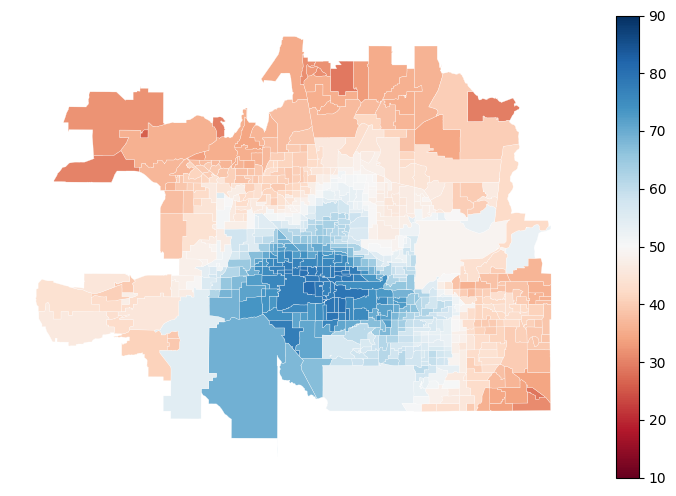

In [7]:
ax = metro_phx.plot(column='pct_dem_lag', cmap='RdBu', legend=True,
                    vmin=10, vmax=90, figsize=(10,6),
                    edgecolor="white", linewidth=0.2)
ax.set_axis_off();

**Comparison of the two maps:**

**Similarities:** The overall spatial pattern is the same — the central/south-central area leans blue (Democrat) and the outer suburban areas lean red/pink (Republican). The broad geographic structure of the political landscape is preserved.

**Differences:** The spatial lag map is noticeably **smoother** than the original. The extreme values (very dark blue or very dark red precincts) are dampened because each precinct's value has been replaced by the average of its neighbors. Sharp local contrasts — such as a single strongly Democratic precinct surrounded by moderate ones — are diminished. The lag map shows more gradual color transitions and less "speckling" of isolated high or low values.

**Why:** This smoothing occurs because the spatial lag computes the weighted average of each precinct's neighbors' values. Averaging inherently reduces extremes and pulls values toward the local mean, producing a less variable and smoother surface.

13. Print the `describe` method for percent votes Democrat and for the lag.

    - Discuss the similarities and differences between the two.
    - Why are the min/max values so different between percent votes data and the lagged data?

In [8]:
metro_phx[['pct_dem', 'pct_dem_lag']].describe()

,pct_dem,pct_dem_lag
count,719.000000,719.000000
mean,52.805186,52.885504
std,13.597986,12.546958
min,22.958501,26.148622
25%,41.682520,42.796868
50%,50.379651,50.587719
75%,62.008366,61.556523
max,89.929742,80.771872


**Similarities:** The mean values are nearly identical (~52.8% for pct_dem vs. ~52.9% for the lag), indicating the spatial lag preserves the overall central tendency. The median and quartile values are also very close between the two.

**Differences:** The standard deviation of the lag (12.55) is lower than the original (13.60), confirming that the lag reduces variability — consistent with its role as a smoother. Both the min and max values are much more compressed for the lag: the original ranges from about 23.0% to 89.9%, while the lag ranges from about 26.1% to 80.8%.

**Why are the min/max values so different?** The spatial lag computes the average of neighboring values, so extreme observations get pulled toward the neighborhood mean. A precinct with 90% Democrat is unlikely to have all neighbors at 90% — its lag will be lower. Similarly, a precinct with 23% Democrat is unlikely to be surrounded entirely by other very-low precincts — its lag will be higher. Averaging always compresses the range of values, eliminating the most extreme outliers.

14. Moran's I
   - Compute Moran's I for percent Democratic votes
   - Print the Moran's I statistic and p-value
   - Explain the null hypothesis
   - Can you reject the null hypothesis at the 0.01 level?
   - Is this positive or negative spatial autocorrelation?

In [9]:
from esda.moran import Moran
from numpy.random import seed

seed(12345)
moran_phx = Moran(metro_phx['pct_dem'], w)
print(f"Moran's I: {moran_phx.I:.4f}")
print(f"p-value:   {moran_phx.p_sim:.4f}")

Moran's I: 0.8616
p-value:   0.0010


**Null hypothesis:** The null hypothesis is **complete spatial randomness** — the observed spatial pattern of percent Democratic votes is no different from what would occur if the values were randomly shuffled across precinct locations.

**Can we reject at 0.01?** Yes. The p-value is 0.001, which is ≤ 0.01, so we reject the null hypothesis at the 0.01 significance level. The observed spatial pattern is extremely unlikely to have arisen by chance.

**Positive or negative?** The Moran's I value of 0.8616 is strongly **positive**, indicating strong positive spatial autocorrelation — precincts with similar Democratic vote percentages cluster together geographically. High-Democrat precincts neighbor other high-Democrat precincts, and low-Democrat precincts neighbor other low-Democrat precincts.

15. Repeat the previous question for Graham County.

In [10]:
# Subset to Graham County
graham = votes.loc[votes.cnty_name == 'Graham',].copy()
graham = graham.to_crs(2223)
graham['pct_dem'] = (graham['votes_dem'] / graham['votes_total']) * 100

# Create queen weights and row standardize
w_graham = Queen.from_dataframe(graham)
w_graham.transform = 'R'

# Compute Moran's I
seed(12345)
moran_graham = Moran(graham['pct_dem'], w_graham)
print(f"Moran's I: {moran_graham.I:.4f}")
print(f"p-value:   {moran_graham.p_sim:.4f}")

Moran's I: 0.1803
p-value:   0.0370


**Null hypothesis:** Complete spatial randomness — the spatial arrangement of percent Democratic votes in Graham County is no different from a random assignment of values to locations.

**Can we reject at 0.01?** No. The p-value is 0.037, which is greater than 0.01. We cannot reject the null hypothesis at the 0.01 level (though we could at the 0.05 level).

**Positive or negative?** The Moran's I value of 0.1803 is **positive**, suggesting some mild positive spatial autocorrelation. However, with only a few precincts in a small rural county, the evidence for spatial autocorrelation is much weaker than for the metro Phoenix area (I = 0.86).

16. Moran plots.
   - Run `plot_moran` on Graham County
   - Run `plot_moran` on `metro_phx`
   - Explain generally what the scatterplot demonstrates.
   - Explain generally what the reference distribution demonstrates.
   - Describe how the plots differ for the two regions.

Graham County:


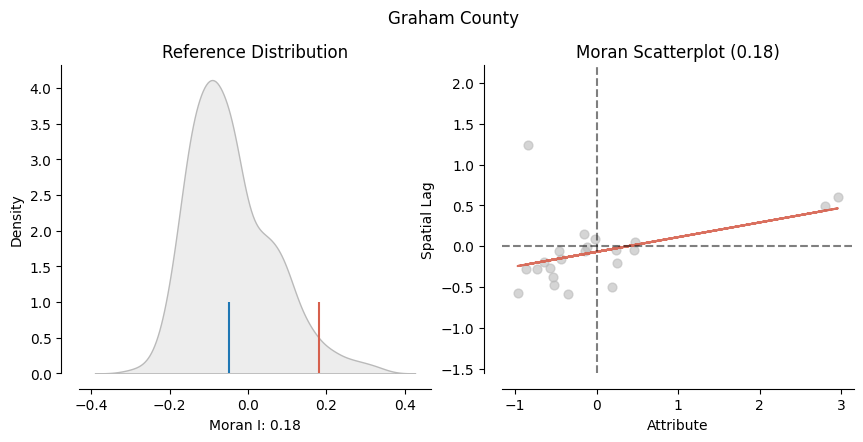


Metro Phoenix:


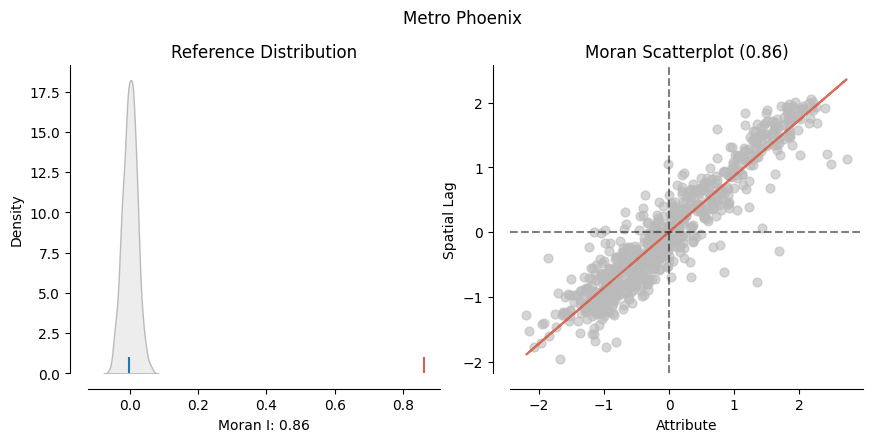

In [12]:
from splot.esda import plot_moran
import matplotlib.pyplot as plt

print("Graham County:")
plot_moran(moran_graham, zstandard=True)
plt.suptitle("Graham County", y=1.02)
plt.show()

print("\nMetro Phoenix:")
plot_moran(moran_phx, zstandard=True)
plt.suptitle("Metro Phoenix", y=1.02)
plt.show()

**What the scatterplot demonstrates:** The Moran Scatterplot shows each observation's standardized value (deviation from mean) on the x-axis against the standardized spatial lag on the y-axis. The red regression line's slope equals Moran's I. Points in the upper-right and lower-left quadrants (similar values near similar values) indicate positive spatial autocorrelation, while points in the upper-left and lower-right quadrants (dissimilar neighbors) indicate negative spatial autocorrelation.

**What the reference distribution demonstrates:** The reference distribution (left panel) shows the empirical distribution of Moran's I values from 999 random permutations of the data (the null hypothesis of spatial randomness). The blue rug marks the mean of the simulated distribution (expected value under randomness, near zero), and the red rug marks the observed Moran's I value. If the red rug is far from the grey distribution, the observed pattern is unlikely to be due to chance.

**How the plots differ:**
- **Metro Phoenix (I = 0.86):** The scatterplot shows a tight, steep positive trend — most points fall in the upper-right (high-high) or lower-left (low-low) quadrants, confirming strong positive spatial autocorrelation. In the reference distribution, the observed Moran's I (red rug at 0.86) is far to the right of the simulated distribution (clustered around 0), demonstrating that this level of spatial autocorrelation is extremely unlikely under randomness.
- **Graham County (I = 0.18):** The scatterplot shows a scattered, weakly positive trend — points are dispersed across all four quadrants with only a slight tendency toward the positive quadrants. The regression line is nearly flat. In the reference distribution, the observed value (red rug at 0.18) is only slightly to the right of the simulated distribution, indicating weaker evidence of spatial autocorrelation compared to metro Phoenix.

17. Run the following cell. It reads in the fires dataset, subsets it to California and two fire cause types and presents some preliminary output. Be sure you understand everything in the cell. The resulting map presents the origin point of each fire, classed by how the fire started. This is in effect a binary variable since there are two possible causes.

    Generally, does fire cause appear to be a case of positive spatial autocorrelation, negative spatial autocorrelation or neither? Explain.

STAT_CAUSE_DESCR
Lightning    1469
Arson         889
Name: count, dtype: int64


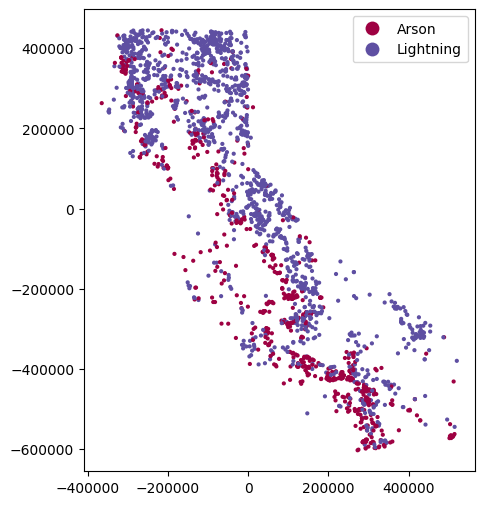

In [13]:
# Read in fires data
fires = pd.read_csv('data/fpa_az_ca_fires.csv')
# Convert to GeoDataFrame
pt_geoms = gpd.points_from_xy(x=fires["LONGITUDE"],
                              y=fires["LATITUDE"],
                              crs="EPSG:4326")
fires = gpd.GeoDataFrame(fires, geometry=pt_geoms)
# Subset to just two fire cause types
fires = fires.loc[fires.STAT_CAUSE_DESCR.isin(['Lightning',
                                               'Arson']),]
# Subset to California
fires = fires.loc[fires.STATE=='CA',]
# Reproject to California Albers
fires = fires.to_crs(3310)
# Print out fire cause counts
print(fires.STAT_CAUSE_DESCR.value_counts())
# Create map
fires.plot(column='STAT_CAUSE_DESCR', categorical=True,
           cmap='Spectral', markersize=4, legend=True,
           figsize=(6,6));

The map generally appears to show **positive spatial autocorrelation** for fire cause. Lightning fires (purple) tend to cluster together in certain areas — particularly in the mountainous and forested regions of northern California and the Sierra Nevada. Arson fires (red) also tend to cluster, appearing more concentrated in the urban corridors and southern California. There are regions where the two types intermix, but the overall pattern shows spatial grouping of similar fire cause types rather than a random mix, which is consistent with positive spatial autocorrelation.

This makes geographic sense: lightning fires are concentrated where thunderstorms and dry forests coincide (mountains), while arson fires are more common near populated areas.

18. Join count statistic.
    - Create a KNN spatial weights matrix for `fires` with 8 nearest neighbors
    - Add a binary column to `fires` indicating if the cause was Lightning (1) or Arson (0)
    - Compute the join count statistic for the binary column you created and using the weights matrix you created
    - Print the join count statistic value and p-value for the bb and bw cases
    - The null hypothesis for each case is spatial randomness. What does it mean to reject the null hypothesis in the bb case? What about the bw case?
    - Can you reject the bb case for this dataset? What about the bw case? What does this imply for this dataset?

In [14]:
from libpysal.weights import KNN
from esda.join_counts import Join_Counts

# KNN weights with 8 neighbors
w_fires = KNN.from_dataframe(fires, k=8)

# Binary column: Lightning = 1, Arson = 0
fires['is_lightning'] = (fires['STAT_CAUSE_DESCR'] == 'Lightning').astype(int)

# Join count statistic (must use binary/original weights)
w_fires.transform = 'O'
seed(12345)
jc = Join_Counts(fires['is_lightning'], w_fires)

print(f"BB (Lightning-Lightning) joins: {jc.bb}")
print(f"BW (Lightning-Arson) joins:     {jc.bw}")
print(f"p-value for BB: {jc.p_sim_bb:.4f}")
print(f"p-value for BW: {jc.p_sim_bw:.4f}")

BB (Lightning-Lightning) joins: 4916.5
BW (Lightning-Arson) joins:     1911.0
p-value for BB: 0.0010
p-value for BW: 1.0000


In [15]:
print(f"Expected BB under randomness: {jc.mean_bb:.1f}")
print(f"Expected BW under randomness: {jc.mean_bw:.1f}")

Expected BB under randomness: 3660.6
Expected BW under randomness: 4431.0


**BB case null hypothesis:** Under spatial randomness, lightning fires would be randomly scattered across locations. Rejecting the null means that lightning fires are significantly more clustered together (more lightning-lightning neighbor pairs) than would be expected by chance.

**BW case null hypothesis:** Under spatial randomness, the number of cross-category neighbor pairs (lightning next to arson) would match random expectations. Rejecting the null would mean there are significantly more (or fewer) mixed pairs than expected.

**Results for this dataset:**
- **BB (p = 0.001):** We reject the null at the 0.01 level. There are 4,917 lightning-lightning joins, far more than the ~3,661 expected under randomness. Lightning fires significantly cluster together spatially.
- **BW (p = 1.000):** We cannot reject the null. There are only 1,911 cross-category joins, far fewer than the ~4,431 expected under randomness. The p-value of 1.0 means the observed BW count was lower than every simulated count — there are significantly fewer mixed pairs than expected.

**Implication:** Both results confirm strong **positive spatial autocorrelation** — fires of the same cause type tend to be located near each other. Lightning fires cluster in certain regions (mountains/forests) and arson fires cluster in others (urban areas), with relatively little mixing between the two types.

19. Run the Getis-Ord G separately for fires caused by lightning and those caused by arson. For each case:
    - Create a distance band spatial weights matrix set to 100 km
    - Compute G for `FIRE_SIZE`
    - Print the G statistic and associated p-value

In [16]:
from libpysal.weights import DistanceBand
from esda.getisord import G

# Separate fires by cause
lightning = fires.loc[fires.STAT_CAUSE_DESCR == 'Lightning'].copy()
arson = fires.loc[fires.STAT_CAUSE_DESCR == 'Arson'].copy()

# --- Lightning fires ---
# Distance band weights at 100 km (CRS 3310 is in meters)
w_light = DistanceBand.from_dataframe(lightning, threshold=100000)
seed(12345)
g_light = G(lightning['FIRE_SIZE'], w_light)
print("Lightning fires:")
print(f"  G statistic: {g_light.G:.6f}")
print(f"  p-value:     {g_light.p_sim:.4f}")

# --- Arson fires ---
w_arson = DistanceBand.from_dataframe(arson, threshold=100000)
seed(12345)
g_arson = G(arson['FIRE_SIZE'], w_arson)
print("\nArson fires:")
print(f"  G statistic: {g_arson.G:.6f}")
print(f"  p-value:     {g_arson.p_sim:.4f}")

Lightning fires:
  G statistic: 0.140244
  p-value:     0.0210

Arson fires:
  G statistic: 0.186673
  p-value:     0.0910


20. Interpret the results from the previous question. For each fire type:
    - Explain the null hypothesis and whether or not you can reject it at the 0.05 level.
    - Is the G stat positive or negative? What does this mean about the spatial pattern of fire sizes?

**Lightning fires (G = 0.1402, p = 0.021):**
- The null hypothesis is that fire sizes are randomly distributed across locations — there is no spatial concentration of large or small fires.
- At the 0.05 level, we **can reject** the null hypothesis (p = 0.021 < 0.05). There is statistically significant evidence of spatial concentration of fire sizes among lightning-caused fires.
- The G statistic is positive, indicating that fires of similar sizes tend to co-locate — large lightning fires tend to be near other large lightning fires. This makes sense geographically, as conditions favorable for large lightning fires (dry forests, remote terrain) tend to cluster in certain regions.

**Arson fires (G = 0.1867, p = 0.091):**
- The null hypothesis is the same — fire sizes are randomly distributed across locations.
- At the 0.05 level, we **cannot reject** the null hypothesis (p = 0.091 > 0.05). There is not sufficient evidence to conclude that arson fire sizes exhibit spatial concentration.
- The G statistic is positive, suggesting some tendency for similarly-sized arson fires to co-locate, but the evidence is not strong enough to rule out chance at the 0.05 level. Arson fire sizes appear to be more spatially random than lightning fire sizes.